# Introduction

Ce notebook présente une simulation d’une urne de Pólya généralisée. Le modèle est simple : deux couleurs, noir et blanc, et un mécanisme de renforcement qui dépend de la couleur tirée.

## Modèle mathématique

L’état de l’urne à l’instant $n$ est donné par
$$S_n = (B_n, W_n),$$
avec $B_n$ le nombre de boules noires et $W_n$ le nombre de boules blanches.

La probabilité de tirer une boule noire est
$$\mathbb{P}(\text{noir à l’étape } n) = \frac{B_n}{B_n + W_n}.
$$
Après chaque tirage, la couleur observée est renforcée par un nombre de boules supplémentaire.

In [12]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

from src.urn import PolyaUrn

## Paramètres de simulation

Nous définissons l’urne initiale et les paramètres de renforcement :

- état initial : $B_0 = 10$, $W_0 = 5$,
- renforcement noir : $a = 2$,
- renforcement blanc : $b = 1$.

Le paramètre de renforcement mesure l’effet de chaque tirage sur les tirages futurs.

In [13]:
urn = PolyaUrn(
    balls={"black": 10, "white": 5},
    reinforcements={"black": 2, "white": 1}
)

## Procédure de simulation

La procédure de simulation est la suivante :
1. on tire une boule au hasard selon la composition actuelle,
2. on observe sa couleur,
3. on ajoute le nombre de boules correspondant à cette couleur.

La trajectoire stochastique est ainsi définie par la suite des états successifs de l’urne.

In [14]:
for _ in range(10):
    print(urn.draw())

black
black
black
black
black
black
black
black
black
white


## État final et dépendance au passé

L’état final de l’urne après les tirages montre l’effet cumulé des renforcements. Chaque tirage influence la composition future, ce qui introduit une dépendance forte au passé.

In [15]:
urn.balls

{'black': 28, 'white': 6}

## Premières trajectoires

Nous extrayons maintenant les trajectoires du nombre de boules noires et blanches dans l’historique. Ces trajectoires montrent l’évolution absolue des compteurs.

In [16]:
black_counts = [
    state["black"]
    for state in urn.history
]

white_counts = [
    state["white"]
    for state in urn.history
]

## Visualisation des trajectoires

Le graphique suivant illustre les trajectoires des deux couleurs. Il permet d’observer si l’une des deux couleurs domine par renforcement successif.

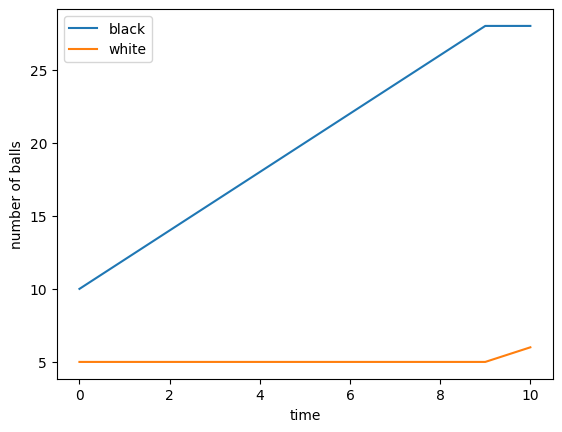

In [17]:
import matplotlib.pyplot as plt

plt.plot(black_counts, label="black")
plt.plot(white_counts, label="white")

plt.xlabel("time")
plt.ylabel("number of balls")

plt.legend()

plt.show()

## Évolution des proportions

Les proportions sont des quantités relatives qui rendent mieux compte de la composition de l’urne.
Nous calculons la proportion de boules noires :
$
\frac{B_n}{B_n + W_n}
$

Cette quantité est une trajectoire stochastique sur $[0,1]$.

In [18]:
proportions_black = [
    state["black"] /
    (state["black"] + state["white"])
    for state in urn.history
]

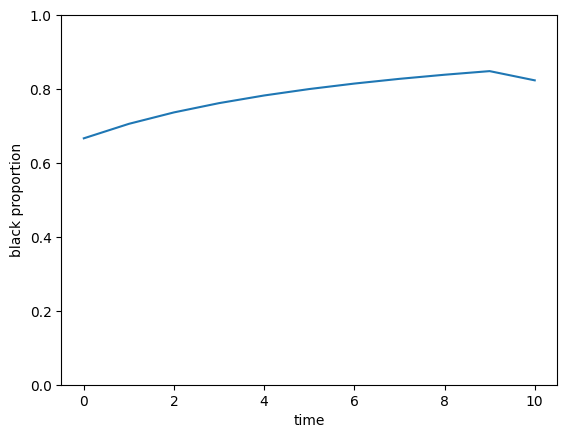

In [19]:
plt.plot(proportions_black)

plt.xlabel("time")
plt.ylabel("black proportion")

plt.ylim(0, 1)

plt.show()

## Interprétation probabiliste

La dynamique des proportions montre l’influence du renforcement :
- si les tirages noirs sont fréquents, la proportion noire augmente,
- si les tirages blancs dominent, la proportion noire diminue.

Le modèle illustre une dépendance au passé, car les probabilités de tirage évoluent avec la composition actuelle de l’urne.